In [71]:
# Data Science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import re
import seaborn as sns
from tqdm.notebook import tqdm
import pgeocode

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# Handling class imbalance
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline  # replaces sklearn Pipeline when using SMOTE
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Models and evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, StratifiedKFold

# Linear Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LearningCurveDisplay

# Tree-based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer,
    fbeta_score,
    matthews_corrcoef,
    precision_recall_curve
)
from MLstatkit import Delong_test
from mlxtend.evaluate import cochrans_q, mcnemar, mcnemar_table
from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar


# Preprocessing

In [2]:
clinical = pd.read_csv("../hantavirus_data/hantavirus_clinical.csv")
clinical

,patient_id,year,country,syndrome,age,sex,symptoms,incubation_days,severity,hospitalized,...,dialysis,comorbidity,exposure_type,outcome,length_of_stay_days,blood_type,viral_load_category,days_to_diagnosis,treatment_protocol,geographic_setting
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,"Hypotension, Chills, Abdominal Pain, Vomiting,...",22,Severe,1,...,0,NaN,Cruise ship exposure,Deceased,6,O+,High,2,Vasopressors + mechanical ventilation,Remote
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,"Pulmonary Edema, Hypotension, Dyspnea, Cough",13,Severe,1,...,0,Hypertension,Cruise ship exposure,Deceased,28,A+,Low,3,ECMO + full ICU support,Remote
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,"Vomiting, Chills, Hypotension, Myalgia, Tachyc...",9,Critical,1,...,0,Immunosuppression,Cruise ship exposure,Deceased,19,O+,Low,4,ECMO + full ICU support,Remote
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,"Diarrhea, Myalgia, Nausea, Chills, Dizziness, ...",21,Critical,1,...,0,Asthma,Cruise ship exposure,Recovered,22,O-,Critical,5,Vasopressors + mechanical ventilation,Remote
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,"Chills, Fever, Pulmonary Edema, Myalgia",12,Severe,1,...,0,Cardiovascular Disease,Cruise ship exposure,Recovered,14,A+,High,5,Supportive care only,Remote
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,"Dizziness, Headache, Pulmonary Edema",29,Severe,1,...,0,NaN,Rural dwelling,Recovered,17,A+,Low,7,Dialysis + supportive,Rural
9996,PT-09997,2019,Canada,HPS,58,Female,"Hypotension, Vomiting, Myalgia, Diarrhea, Fati...",20,Severe,1,...,0,NaN,Camping/hiking,Deceased,10,AB+,High,1,Vasopressors + mechanical ventilation,Urban
9997,PT-09998,2015,Colombia,HPS,21,Female,"Tachycardia, Cough, Dizziness",24,Severe,1,...,0,Hypertension,Cleaning rodent-infested area,Recovered,16,O+,Critical,1,IV fluids + oxygen,Peri-urban
9998,PT-09999,2004,South Korea,HFRS,24,Female,"Petechiae, Headache, Blurred Vision",28,Moderate,1,...,0,Smoking,Agricultural work,Recovered,15,A+,Low,8,IV fluids + oxygen,Remote


In [3]:
country_yearly = pd.read_csv("../hantavirus_data/hantavirus_country_yearly.csv")
country_yearly

,year,iso3,country,who_region,latitude,longitude,syndrome,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases
0,1993,ARG,Argentina,AMRO,-34.60,-58.40,HPS,35,11,24,0.3426,30,8,0
1,1993,CHL,Chile,AMRO,-33.40,-70.60,HPS,0,0,0,0.2587,0,0,0
2,1993,BRA,Brazil,AMRO,-15.80,-47.90,HPS,0,0,0,0.4455,0,0,0
3,1993,BOL,Bolivia,AMRO,-16.50,-68.20,HPS,0,0,0,0.2775,0,0,0
4,1993,PRY,Paraguay,AMRO,-25.30,-57.60,HPS,0,0,0,0.2666,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,2026,FRA,France,EURO,48.90,2.30,HFRS,101,0,101,0.0012,82,26,0
846,2026,HRV,Croatia,EURO,45.80,16.00,HFRS,82,2,80,0.0349,76,14,0
847,2026,SVN,Slovenia,EURO,46.10,14.50,HFRS,46,1,45,0.0307,40,12,0
848,2026,GRC,Greece,EURO,37.97,23.73,HFRS,12,0,12,0.0262,10,2,0


In [4]:
# Merge clinical and country_yearly on country and year

# Add prefix to country_yearly columns before merging
country_yearly_prefixed = country_yearly.add_prefix('cy_')

# Rename the merge keys back so the join works
country_yearly_prefixed = country_yearly_prefixed.rename(columns={
    'cy_country': 'country',
    'cy_year': 'year'
})

# Merge
data = pd.merge(clinical, country_yearly_prefixed, on=["country", "year"], how="left")

In [5]:
# Drop erroneous columns

# Drop the WHO region, since we have country level data and latitude/longitude
data = data.drop(columns=["cy_who_region"])

# Drop the cy_isoo3 column, since it is just a repeat of the iso3 column
data = data.drop(columns=["cy_iso3"])

# Drop the cy_syndrome column, since it is just a repeat of the syndrome column
data = data.drop(columns=["cy_syndrome"])

data

,patient_id,year,country,syndrome,age,sex,symptoms,incubation_days,severity,hospitalized,...,geographic_setting,cy_latitude,cy_longitude,cy_confirmed_cases,cy_deaths,cy_recovered,cy_case_fatality_rate,cy_hospitalized,cy_icu_admissions,cy_human_to_human_cases
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,"Hypotension, Chills, Abdominal Pain, Vomiting,...",22,Severe,1,...,Remote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,"Pulmonary Edema, Hypotension, Dyspnea, Cough",13,Severe,1,...,Remote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,"Vomiting, Chills, Hypotension, Myalgia, Tachyc...",9,Critical,1,...,Remote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,"Diarrhea, Myalgia, Nausea, Chills, Dizziness, ...",21,Critical,1,...,Remote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,"Chills, Fever, Pulmonary Edema, Myalgia",12,Severe,1,...,Remote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,"Dizziness, Headache, Pulmonary Edema",29,Severe,1,...,Rural,38.9,-77.0,58.0,17.0,41.0,0.3067,50.0,8.0,0.0
9996,PT-09997,2019,Canada,HPS,58,Female,"Hypotension, Vomiting, Myalgia, Diarrhea, Fati...",20,Severe,1,...,Urban,45.4,-75.7,3.0,0.0,3.0,0.3038,2.0,0.0,0.0
9997,PT-09998,2015,Colombia,HPS,21,Female,"Tachycardia, Cough, Dizziness",24,Severe,1,...,Peri-urban,4.7,-74.1,7.0,2.0,5.0,0.2997,5.0,0.0,0.0
9998,PT-09999,2004,South Korea,HFRS,24,Female,"Petechiae, Headache, Blurred Vision",28,Moderate,1,...,Remote,37.6,127.0,528.0,8.0,520.0,0.0152,453.0,129.0,0.0


In [6]:
# Process the symptoms column

# Fill nulls first, then split
data['symptoms'] = data['symptoms'].fillna('').str.split(r',\s*')

# Remove empty strings from lists (artifact of splitting empty strings)
data['symptoms'] = data['symptoms'].apply(lambda x: [s for s in x if s])

# Use MultiLabelBinarizer to one-hot encode the symptoms
mlb = MultiLabelBinarizer()
symptoms_encoded = mlb.fit_transform(data['symptoms'])
data_symptoms = pd.DataFrame(symptoms_encoded, columns=[f'sym_{c}' for c in mlb.classes_])

data = pd.concat([data, data_symptoms], axis=1)
data = data.drop(columns=['symptoms'])

data

,patient_id,year,country,syndrome,age,sex,incubation_days,severity,hospitalized,icu_admission,...,sym_Headache,sym_Hypotension,sym_Myalgia,sym_Nausea,sym_Oliguria,sym_Petechiae,sym_Proteinuria,sym_Pulmonary Edema,sym_Tachycardia,sym_Vomiting
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,22,Severe,1,1,...,0,1,0,0,0,0,0,1,0,1
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,13,Severe,1,0,...,0,1,0,0,0,0,0,1,0,0
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,9,Critical,1,1,...,0,1,1,0,0,0,0,0,1,1
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,21,Critical,1,1,...,1,1,1,1,0,0,0,0,0,0
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,12,Severe,1,1,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,29,Severe,1,1,...,1,0,0,0,0,0,0,1,0,0
9996,PT-09997,2019,Canada,HPS,58,Female,20,Severe,1,1,...,0,1,1,0,0,0,0,0,0,1
9997,PT-09998,2015,Colombia,HPS,21,Female,24,Severe,1,1,...,0,0,0,0,0,0,0,0,1,0
9998,PT-09999,2004,South Korea,HFRS,24,Female,28,Moderate,1,0,...,1,0,0,0,0,1,0,0,0,0


In [7]:
# Do Ordinal Encoding on some categorical features

severity_mapping = {
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2,
    'Critical': 3,
}

data['severity_encoded'] = data['severity'].map(severity_mapping)
data.drop(columns=['severity'], inplace=True)

viral_load_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4,
    '': 0  # Assuming empty string means no viral load or unknown
}

data['viral_load_encoded'] = data['viral_load_category'].map(viral_load_mapping)
data.drop(columns=['viral_load_category'], inplace=True)

outcome_mapping = {
    'Recovered': 0,
    'Deceased': 1,
}

data['outcome_encoded'] = data['outcome'].map(outcome_mapping)
data.drop(columns=['outcome'], inplace=True)

data

,patient_id,year,country,syndrome,age,sex,incubation_days,hospitalized,icu_admission,mechanical_ventilation,...,sym_Nausea,sym_Oliguria,sym_Petechiae,sym_Proteinuria,sym_Pulmonary Edema,sym_Tachycardia,sym_Vomiting,severity_encoded,viral_load_encoded,outcome_encoded
0,PT-00001,2026,MV Hondius (International),HPS,82,Male,22,1,1,0,...,0,0,0,0,1,0,1,2,3,1
1,PT-00002,2026,MV Hondius (International),HPS,73,Female,13,1,0,0,...,0,0,0,0,1,0,0,2,1,1
2,PT-00003,2026,MV Hondius (International),HPS,62,Female,9,1,1,0,...,0,0,0,0,0,1,1,3,1,1
3,PT-00004,2026,MV Hondius (International),HPS,82,Female,21,1,1,1,...,1,0,0,0,0,0,0,3,4,0
4,PT-00005,2026,MV Hondius (International),HPS,74,Male,12,1,1,0,...,0,0,0,0,1,0,0,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,USA,HPS,37,Female,29,1,1,0,...,0,0,0,0,1,0,0,2,1,0
9996,PT-09997,2019,Canada,HPS,58,Female,20,1,1,0,...,0,0,0,0,0,0,1,2,3,1
9997,PT-09998,2015,Colombia,HPS,21,Female,24,1,1,0,...,0,0,0,0,0,1,0,2,4,0
9998,PT-09999,2004,South Korea,HFRS,24,Female,28,1,0,0,...,0,0,1,0,0,0,0,1,1,0


In [8]:
# Do OHE encoding on remaining categorical features

# Define a function to OHE encode specified categorical columns
def ohe_encode(df, categorical_cols):
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe_encoded = ohe.fit_transform(df[categorical_cols])
    ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(categorical_cols))
    df = pd.concat([df, ohe_df], axis=1)
    return df


# List of categorical columns to encode
categorical_cols = ['country', 'syndrome', 'sex', 'exposure_type', 'blood_type', 'treatment_protocol', 'geographic_setting', 'comorbidity']

# OHE encode the categorical columns and drop the original columns
data = ohe_encode(data, categorical_cols)
data = data.drop(columns=categorical_cols)

data

,patient_id,year,age,incubation_days,hospitalized,icu_admission,mechanical_ventilation,ecmo_used,dialysis,length_of_stay_days,...,comorbidity_Asthma,comorbidity_COPD,comorbidity_Cardiovascular Disease,comorbidity_Chronic Kidney Disease,comorbidity_Diabetes,comorbidity_Hypertension,comorbidity_Immunosuppression,comorbidity_Obesity,comorbidity_Smoking,comorbidity_nan
0,PT-00001,2026,82,22,1,1,0,0,0,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,PT-00002,2026,73,13,1,0,0,0,0,28,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,PT-00003,2026,62,9,1,1,0,0,0,19,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,PT-00004,2026,82,21,1,1,1,0,0,22,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PT-00005,2026,74,12,1,1,0,0,0,14,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT-09996,2025,37,29,1,1,0,0,0,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9996,PT-09997,2019,58,20,1,1,0,0,0,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9997,PT-09998,2015,21,24,1,1,0,0,0,16,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9998,PT-09999,2004,24,28,1,0,0,0,0,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
# Set patient_id as index

data = data.set_index('patient_id')
data

,year,age,incubation_days,hospitalized,icu_admission,mechanical_ventilation,ecmo_used,dialysis,length_of_stay_days,days_to_diagnosis,...,comorbidity_Asthma,comorbidity_COPD,comorbidity_Cardiovascular Disease,comorbidity_Chronic Kidney Disease,comorbidity_Diabetes,comorbidity_Hypertension,comorbidity_Immunosuppression,comorbidity_Obesity,comorbidity_Smoking,comorbidity_nan
patient_id,,,,,,,,,,,,,,,,,,,,,
PT-00001,2026,82,22,1,1,0,0,0,6,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
PT-00002,2026,73,13,1,0,0,0,0,28,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
PT-00003,2026,62,9,1,1,0,0,0,19,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
PT-00004,2026,82,21,1,1,1,0,0,22,5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PT-00005,2026,74,12,1,1,0,0,0,14,5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-09996,2025,37,29,1,1,0,0,0,17,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
PT-09997,2019,58,20,1,1,0,0,0,10,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
PT-09998,2015,21,24,1,1,0,0,0,16,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [10]:
# Add an indicator for whether the patient's country has metadata
cy_cols = [col for col in data.columns if 'cy_' in col]
data['has_cy_data'] = (~data[cy_cols].isna().any(axis=1)).astype(int)
data

,year,age,incubation_days,hospitalized,icu_admission,mechanical_ventilation,ecmo_used,dialysis,length_of_stay_days,days_to_diagnosis,...,comorbidity_COPD,comorbidity_Cardiovascular Disease,comorbidity_Chronic Kidney Disease,comorbidity_Diabetes,comorbidity_Hypertension,comorbidity_Immunosuppression,comorbidity_Obesity,comorbidity_Smoking,comorbidity_nan,has_cy_data
patient_id,,,,,,,,,,,,,,,,,,,,,
PT-00001,2026,82,22,1,1,0,0,0,6,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
PT-00002,2026,73,13,1,0,0,0,0,28,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
PT-00003,2026,62,9,1,1,0,0,0,19,4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
PT-00004,2026,82,21,1,1,1,0,0,22,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
PT-00005,2026,74,12,1,1,0,0,0,14,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-09996,2025,37,29,1,1,0,0,0,17,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
PT-09997,2019,58,20,1,1,0,0,0,10,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
PT-09998,2015,21,24,1,1,0,0,0,16,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1


# Modelling

In [11]:
def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    recall_died = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    precision_died = classification_report(y_test, y_pred, output_dict=True)['1']['precision']
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Recovered', 'Died'],
        cmap='Blues'
    )
    plt.title(f"{model_name} (threshold={threshold}) — Confusion Matrix")
    plt.show()
    
    return {
        'Model': model_name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'F1 (macro)': f1_macro,
        'Recall (Died)': recall_died,
        'Precision (Died)': precision_died
    }

## Baseline Model

c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


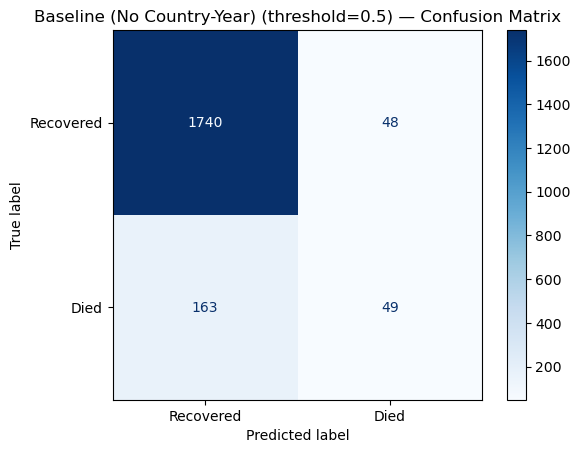

{'Model': 'Baseline (No Country-Year)', 'ROC-AUC': 0.8550346123000295, 'PR-AUC': 0.40226793025105656, 'F1 (macro)': 0.62999301195333, 'Recall (Died)': 0.23113207547169812, 'Precision (Died)': 0.5051546391752577}


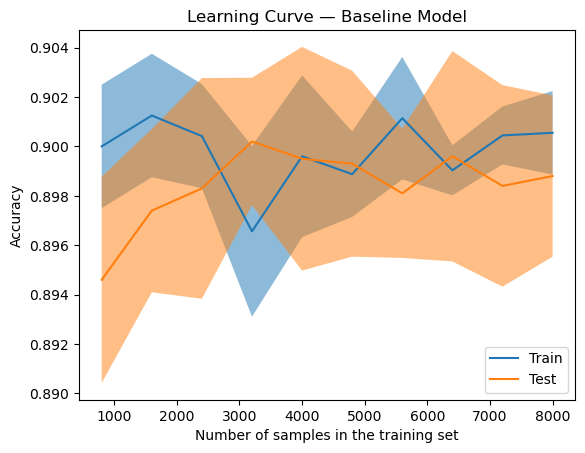

In [12]:
# Create a version of the data without the country-year features for comparison
data_no_cy = data[[col for col in data.columns if 'cy_' not in col]]

# Define X and y for both datasets
X_baseline = data_no_cy.drop(columns=['outcome_encoded'])
y_baseline = data_no_cy['outcome_encoded']

# Train-test split for baseline dataset
X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline
)

# Baseline model training and evaluation
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_baseline, y_train_baseline)
y_pred_baseline = baseline_model.predict(X_test_baseline)

# Evaluate baseline model
baseline_model_results = evaluate_model(baseline_model, X_test_baseline, y_test_baseline, model_name="Baseline (No Country-Year)")
print(baseline_model_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    baseline_model, X_baseline, y_baseline,
    cv=StratifiedKFold(n_splits=5),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — Baseline Model")
plt.show()

## Modelling

In [13]:
X = data.drop(columns=['outcome_encoded'])
y = data['outcome_encoded']

# Train-test split
# Improvement 1: Stratify the split to maintain class balance in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Logistic Regression

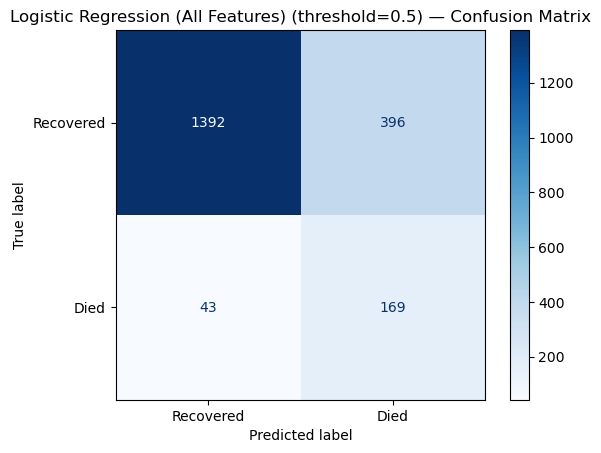

{'Model': 'Logistic Regression (All Features)', 'ROC-AUC': 0.853056012831877, 'PR-AUC': 0.41211036164050163, 'F1 (macro)': 0.6493989668051101, 'Recall (Died)': 0.7971698113207547, 'Precision (Died)': 0.2991150442477876}


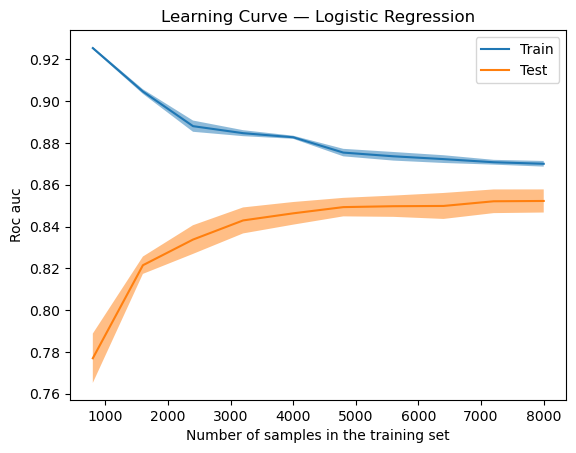

In [14]:
# Model 1: Logistic Regression with all features + high max iterations
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
lr_results = evaluate_model(pipeline_lr, X_test, y_test, "Logistic Regression (All Features)")
print(lr_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_lr, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — Logistic Regression")
plt.show()

In [15]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows).set_index('Threshold')

# Use it
lr_threshold_df = threshold_search(pipeline_lr, X_test, y_test)
lr_threshold_df['Model'] = 'Logistic Regression'
lr_threshold_df = lr_threshold_df.set_index('Model')
lr_threshold_df

,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,
Logistic Regression,0.9906,0.1502,0.3815,0.8531
Logistic Regression,0.9858,0.1719,0.4500,0.8531
Logistic Regression,0.9764,0.1867,0.4874,0.8531
Logistic Regression,0.9575,0.1975,0.5126,0.8531
Logistic Regression,0.8915,0.2059,0.5362,0.8531
Logistic Regression,0.8679,0.2236,0.5653,0.8531
Logistic Regression,0.8302,0.2455,0.5955,0.8531
Logistic Regression,0.8113,0.2743,0.6267,0.8531
Logistic Regression,0.7972,0.2991,0.6494,0.8531


### Random Forest

c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


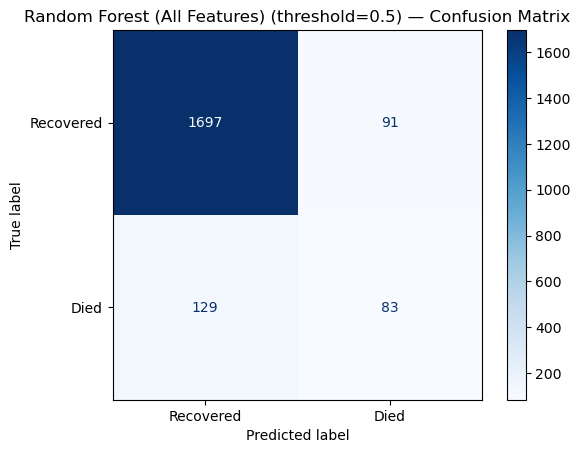

{'Model': 'Random Forest (All Features)', 'ROC-AUC': 0.8562718965007808, 'PR-AUC': 0.4023473775377229, 'F1 (macro)': 0.6845887180251813, 'Recall (Died)': 0.3915094339622642, 'Precision (Died)': 0.47701149425287354}


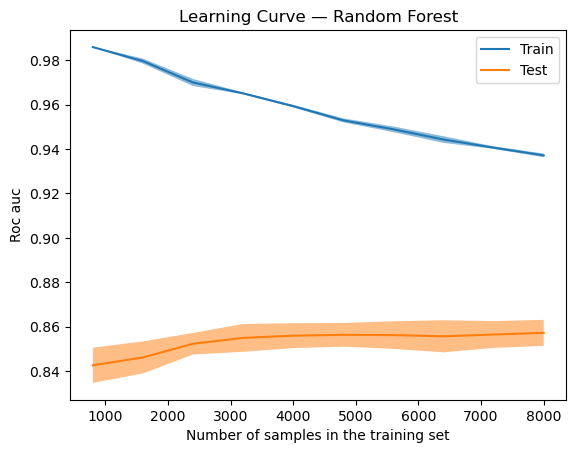

In [16]:
# Model 2: Random Forest with all features + SMOTE for class imbalance + restricted tree depth to prevent overfitting
pipeline_rf = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)
rf_results = evaluate_model(pipeline_rf, X_test, y_test, "Random Forest (All Features)")
print(rf_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_rf, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — Random Forest")
plt.show()

In [17]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows).set_index('Threshold')

# Use it
rf_threshold_df = threshold_search(pipeline_rf, X_test, y_test)
rf_threshold_df['Model'] = 'Random Forest'
rf_threshold_df = rf_threshold_df.set_index('Model')
rf_threshold_df

,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,
Random Forest,0.9387,0.1899,0.5006,0.8563
Random Forest,0.8538,0.2294,0.5743,0.8563
Random Forest,0.8113,0.2770,0.6293,0.8563
Random Forest,0.7783,0.3067,0.6554,0.8563
Random Forest,0.7217,0.3269,0.6687,0.8563
Random Forest,0.6415,0.3409,0.6726,0.8563
Random Forest,0.5425,0.3746,0.6801,0.8563
Random Forest,0.4481,0.4060,0.6770,0.8563
Random Forest,0.3915,0.4770,0.6846,0.8563


### XGBoost

c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:14:28] WARNING: D:\bld\xgboost-split_1772124962567\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


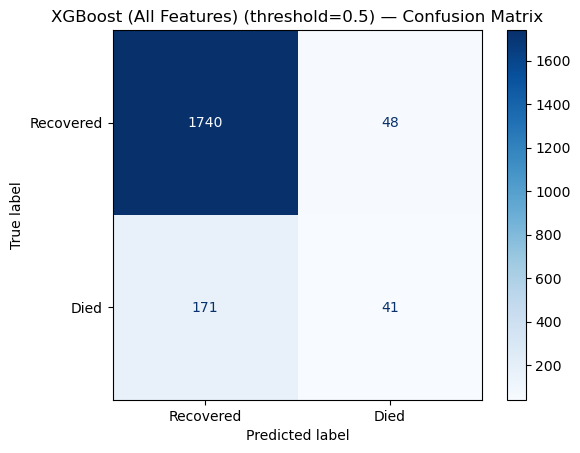

{'Model': 'XGBoost (All Features)', 'ROC-AUC': 0.8490354987125913, 'PR-AUC': 0.36333921528015417, 'F1 (macro)': 0.6066100292886917, 'Recall (Died)': 0.19339622641509435, 'Precision (Died)': 0.4606741573033708}


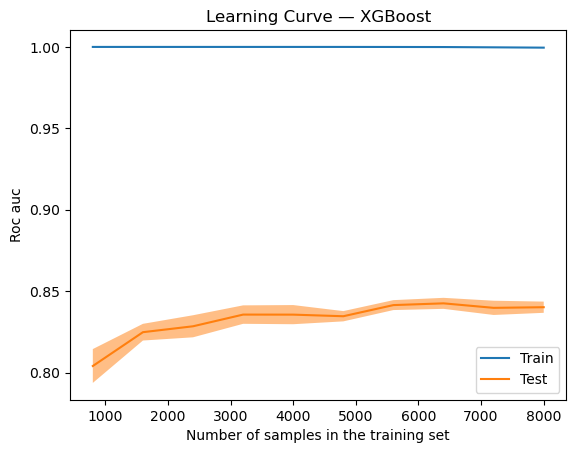

In [18]:
pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)
xgb_results = evaluate_model(pipeline_xgb, X_test, y_test, "XGBoost (All Features)")
print(xgb_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_xgb, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
plt.title("Learning Curve — XGBoost")
plt.show()

In [19]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows).set_index('Threshold')

# Use it
xgb_threshold_df = threshold_search(pipeline_xgb, X_test, y_test)
xgb_threshold_df['Model'] = 'XGBoost'
xgb_threshold_df = xgb_threshold_df.set_index('Model')
xgb_threshold_df

,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,
XGBoost,0.6981,0.3169,0.6603,0.849
XGBoost,0.6179,0.3659,0.6849,0.849
XGBoost,0.5377,0.3878,0.6855,0.849
XGBoost,0.4245,0.3896,0.6662,0.849
XGBoost,0.3868,0.4316,0.6709,0.849
XGBoost,0.3160,0.4295,0.6499,0.849
XGBoost,0.2736,0.4265,0.6349,0.849
XGBoost,0.2217,0.4352,0.6162,0.849
XGBoost,0.1934,0.4607,0.6066,0.849


### LightGBM

c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


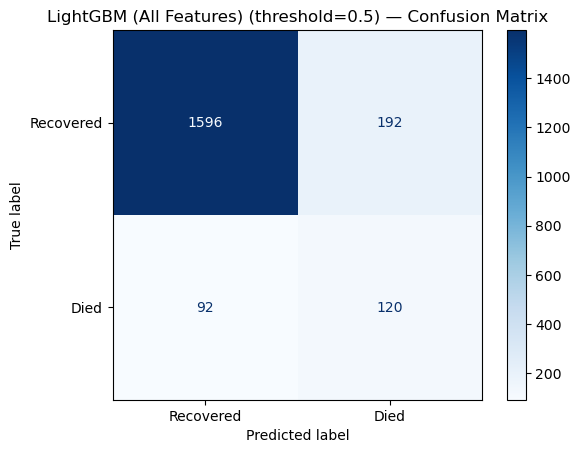

{'Model': 'LightGBM (All Features)', 'ROC-AUC': 0.8510299269764889, 'PR-AUC': 0.3709833402363315, 'F1 (macro)': 0.6881560800780049, 'Recall (Died)': 0.5660377358490566, 'Precision (Died)': 0.38461538461538464}


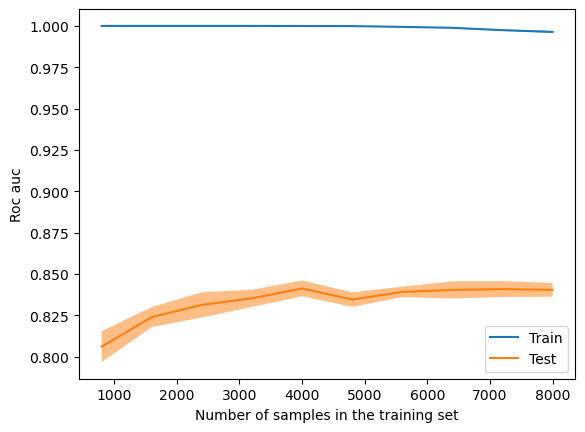

In [20]:
pipeline_lgbm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', LGBMClassifier(
        class_weight='balanced',
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

pipeline_lgbm.fit(X_train, y_train)
lgbm_results = evaluate_model(pipeline_lgbm, X_test, y_test, "LightGBM (All Features)")
print(lgbm_results)

# Learning curve - accuracy scoring
LearningCurveDisplay.from_estimator(
    pipeline_lgbm, X, y,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [21]:
def threshold_search(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rows = []
    for threshold in np.arange(0.1, 0.6, 0.05):
        y_pred_thresh = (y_prob >= threshold).astype(int)
        report = classification_report(y_test, y_pred_thresh, output_dict=True, zero_division=0)
        rows.append({
            'Threshold': round(threshold, 2),
            'Recall (Died)': round(report['1']['recall'], 4),
            'Precision (Died)': round(report['1']['precision'], 4),
            'F1 (macro)': round(f1_score(y_test, y_pred_thresh, average='macro'), 4),
            'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
        })
    
    return pd.DataFrame(rows).set_index('Threshold')

# Use it
lgbm_threshold_df = threshold_search(pipeline_lgbm, X_test, y_test)
lgbm_threshold_df['Model'] = 'LightGBM'
lgbm_threshold_df = lgbm_threshold_df.set_index('Model')
lgbm_threshold_df

c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,
LightGBM,0.9057,0.2251,0.5643,0.851
LightGBM,0.8302,0.2424,0.5919,0.851
LightGBM,0.7877,0.2659,0.6187,0.851
LightGBM,0.7500,0.2901,0.6410,0.851
LightGBM,0.6934,0.3050,0.6513,0.851
LightGBM,0.6557,0.3174,0.6583,0.851
LightGBM,0.6321,0.3445,0.6740,0.851
LightGBM,0.6038,0.3721,0.6867,0.851
LightGBM,0.5660,0.3846,0.6882,0.851


In [22]:
pd.concat([lr_threshold_df, rf_threshold_df, lgbm_threshold_df, xgb_threshold_df], axis=0)

,Recall (Died),Precision (Died),F1 (macro),ROC-AUC
Model,,,,
Logistic Regression,0.9906,0.1502,0.3815,0.8531
Logistic Regression,0.9858,0.1719,0.4500,0.8531
Logistic Regression,0.9764,0.1867,0.4874,0.8531
Logistic Regression,0.9575,0.1975,0.5126,0.8531
Logistic Regression,0.8915,0.2059,0.5362,0.8531
Logistic Regression,0.8679,0.2236,0.5653,0.8531
Logistic Regression,0.8302,0.2455,0.5955,0.8531
Logistic Regression,0.8113,0.2743,0.6267,0.8531
Logistic Regression,0.7972,0.2991,0.6494,0.8531


## Tuning

In [23]:
# Calibrating models
def plot_calibration_curve(y_true, probs, bins, strategy):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, probs, n_bins=bins, strategy=strategy)
    
    max_val = max(mean_predicted_value)
    plt.figure(figsize=(8,10))
    plt.subplot(2, 1, 1)
    plt.plot(mean_predicted_value, fraction_of_positives, label='Random Forests') 
    plt.plot(
        np.linspace(0, max_val, bins), 
        np.linspace(0, max_val, bins), 
        linestyle='--', 
        color='red', 
        label='Perfect calibration'
    ) 
    plt.xlabel('Probability Predictions') 
    plt.ylabel('Fraction of positive examples')
    plt.title('Calibration Curve') 
    plt.legend(loc='upper left') 
    plt.subplot(2, 1, 2) 
    plt.hist(probs, range=(0, 1), bins=bins, density=True, stacked=True, alpha=0.3) 
    plt.show()

def calibrate_and_plot(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    
    # Get uncalibrated probabilities
    probs = model.predict_proba(X_test)[:, 1]
    plot_calibration_curve(y_test, probs, bins=8, strategy='uniform')
    
    # Calibrate with sigmoid method
    clf_sigmoid = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=5)
    clf_sigmoid.fit(X_train, y_train)
    probs_sigmoid = clf_sigmoid.predict_proba(X_test)[:, 1]
    plot_calibration_curve(y_test, probs_sigmoid, bins=8, strategy='uniform')
    
    return clf_sigmoid

In [24]:
# Generate out-of-fold predictions for the training set to use for calibration of the final model
# Reason: we want to use the training data to fit the calibration model, but we can't use the same predictions that were used to train the model (would be data leakage). By using out-of-fold predictions, we get "fresh" predictions for each training example that were not used in training, which can be safely used for calibration. This is done through CV.

def generate_oof_predictions(model, X_train, y_train):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_probs = np.zeros(len(y_train))
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        fold_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=5)
        fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        oof_probs[val_idx] = fold_model.predict_proba(X_train.iloc[val_idx])[:, 1]
    
    return oof_probs

In [25]:
# Optimize thresholds for F2 score and MCC

def optimize_thresholds(model_name, y_true, y_probs):
    thresholds = np.linspace(0.01, 1, 100)
    best_f2 = -1
    best_mcc = -1
    opt_thresh_f2 = 0.5
    opt_thresh_mcc = 0.5
    threshold_df = pd.DataFrame(columns=['Model', 'Threshold', 'F2 Score', 'MCC'])
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        f2 = fbeta_score(y_true, preds, beta=2)
        mcc = matthews_corrcoef(y_true, preds)
        
        if f2 > best_f2:
            best_f2 = f2
            opt_thresh_f2 = t
            
        if mcc > best_mcc:
            best_mcc = mcc
            opt_thresh_mcc = t
        
        threshold_df = pd.concat([threshold_df, pd.DataFrame({
            'Model': [model_name],
            'Threshold': [t],
            'F2 Score': [f2],
            'MCC': [mcc]
        })], ignore_index=True)
    
    return opt_thresh_f2, opt_thresh_mcc, threshold_df

In [26]:
def grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='average_precision',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

### Logistic Regression

In [30]:
lr_parameters = [
    # lbfgs - l2 penalty only
    {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['lbfgs', 'newton-cholesky'],
        'classifier__l1_ratio': [0],  # l1_ratio is ignored when penalty is 'l2'
        'classifier__max_iter': [500, 1000, 5000]
    },
    # saga - supports elasticnet
    {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['saga'],
        'classifier__l1_ratio': [0, 0.5, 1],
        'classifier__max_iter': [500, 1000, 5000]
    }
]

In [ ]:
best_estimator_lr, best_params_lr, best_score_lr = grid_search(pipeline_lr, lr_parameters, X_train, y_train)
clean_params_lr = {k.replace('classifier__', ''): v for k, v in best_params_lr.items()}
tuned_pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        **clean_params_lr
    ))
])

calibrated_lr = calibrate_and_plot(tuned_pipeline_lr, X_train, y_train, X_test, y_test)
oof_probs_lr = generate_oof_predictions(tuned_pipeline_lr, X_train, y_train)
thresh_f2_lr, thresh_mcc_lr, threshold_df_lr = optimize_thresholds("Logistic Regression", y_test, tuned_pipeline_lr.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_lr)
print("Optimal threshold for MCC:", thresh_mcc_lr)
threshold_df_lr

Fitting 5 folds for each of 60 candidates, totalling 300 fits


### Random Forest

In [33]:
rf_parameters = {
    'classifier__n_estimators': [50, 100, 200, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__n_jobs': [-1]
}

Fitting 5 folds for each of 144 candidates, totalling 720 fits


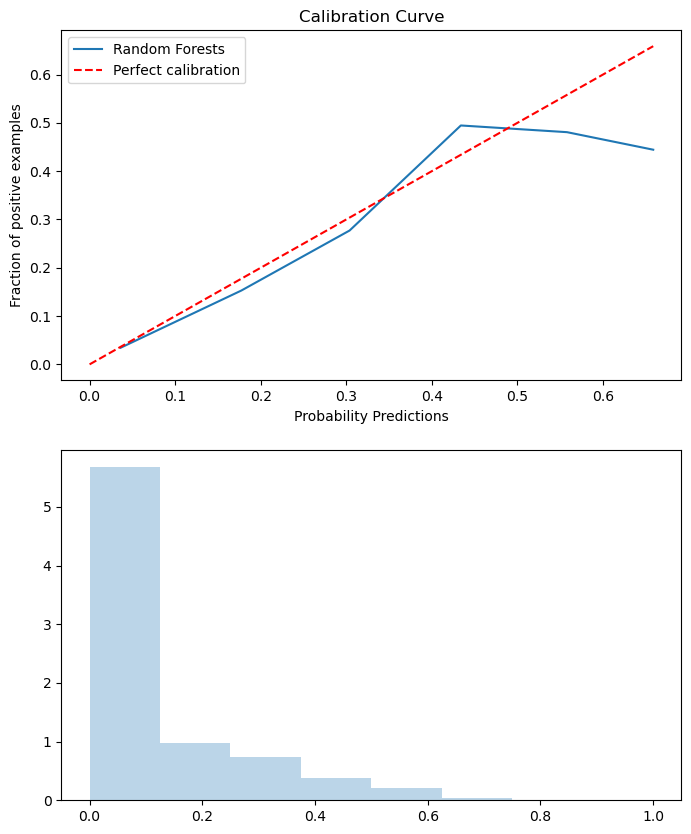

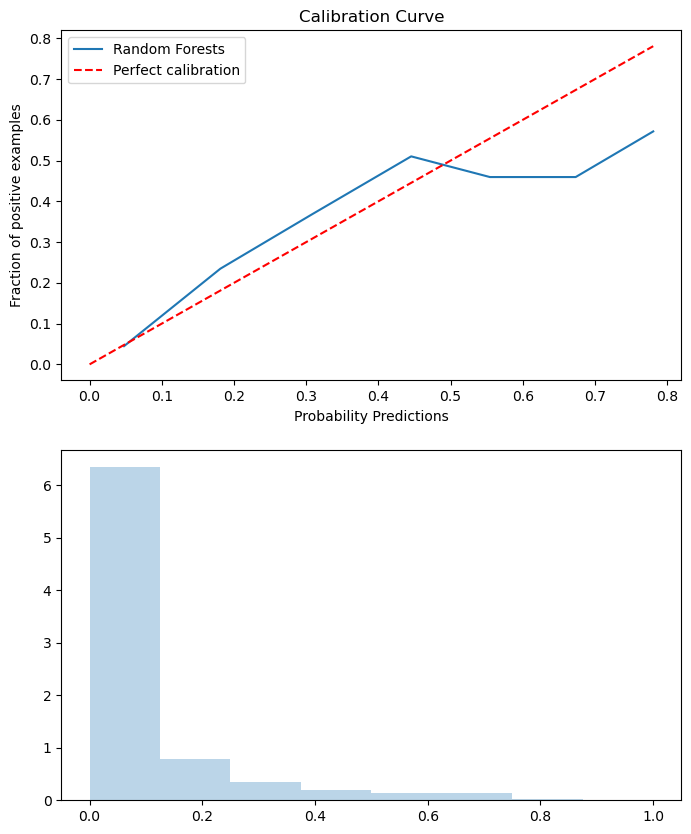

Optimal threshold for F2 score: 0.16
Optimal threshold for MCC: 0.27


,Model,Threshold,F2 Score,MCC
0,Random Forest,0.01,0.426483,0.160163
1,Random Forest,0.02,0.472851,0.225216
2,Random Forest,0.03,0.501688,0.260548
3,Random Forest,0.04,0.517766,0.27842
4,Random Forest,0.05,0.533723,0.296734
...,...,...,...,...
95,Random Forest,0.96,0.0,0.0
96,Random Forest,0.97,0.0,0.0
97,Random Forest,0.98,0.0,0.0
98,Random Forest,0.99,0.0,0.0


In [34]:
best_estimator_rf, best_params_rf, best_score_rf = grid_search(pipeline_rf, rf_parameters, X_train, y_train)
clean_params_rf = {k.replace('classifier__', ''): v for k, v in best_params_rf.items()}
tuned_pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        **clean_params_rf
    ))
])

calibrated_rf = calibrate_and_plot(tuned_pipeline_rf, X_train, y_train, X_test, y_test)
oof_probs_rf = generate_oof_predictions(tuned_pipeline_rf, X_train, y_train)
thresh_f2_rf, thresh_mcc_rf, threshold_df_rf = optimize_thresholds("Random Forest", y_test, tuned_pipeline_rf.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_rf)
print("Optimal threshold for MCC:", thresh_mcc_rf)
threshold_df_rf

### XGBoost

In [35]:
xgb_parameters = {
    'classifier__n_estimators': [50, 100, 200, 500],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
}

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\sweek\miniforge3\envs\sp26\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:15:51] WARNING: D:\bld\xgboost-split_1772124962567\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


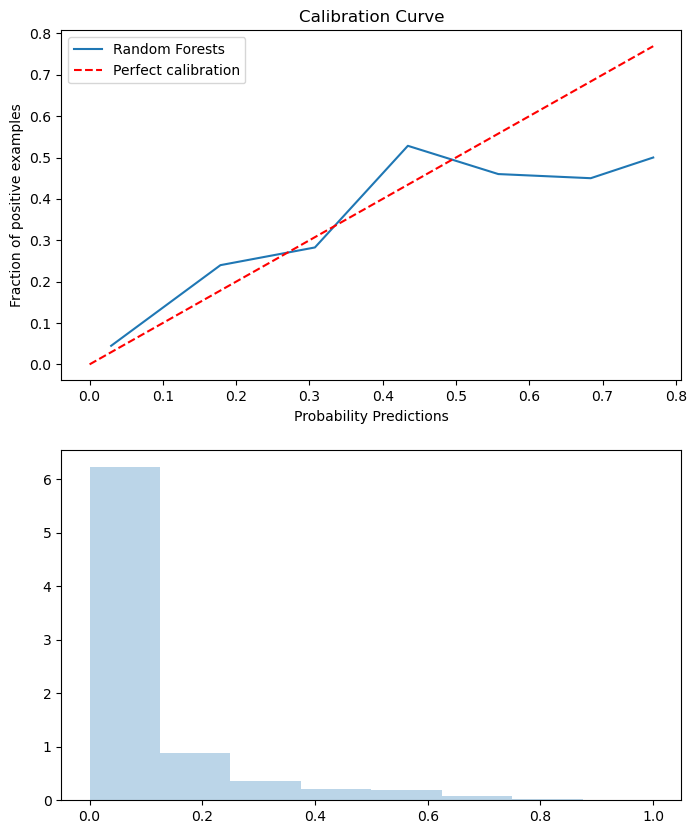

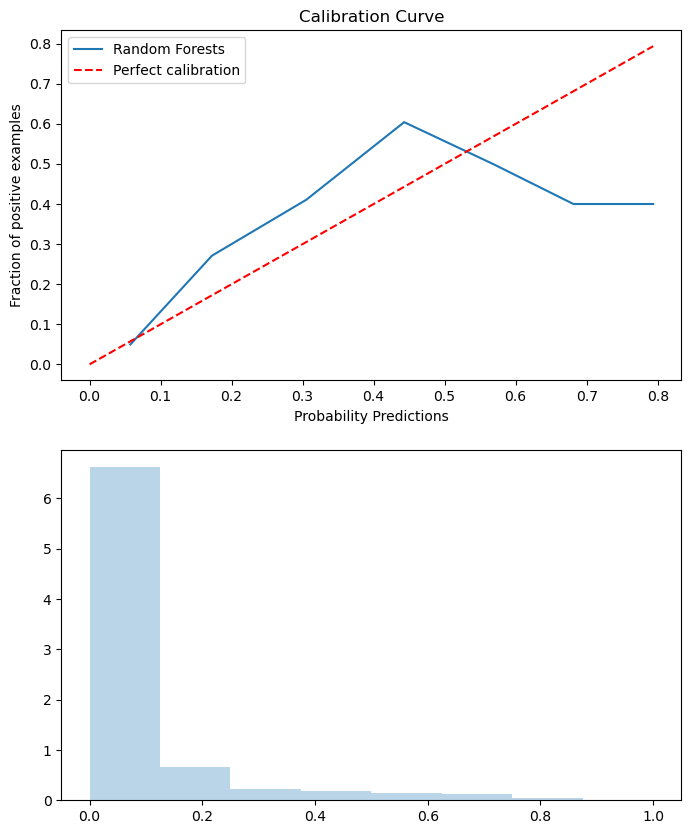

Optimal threshold for F2 score: 0.06999999999999999
Optimal threshold for MCC: 0.18000000000000002


,Model,Threshold,F2 Score,MCC
0,XGBoost,0.01,0.459695,0.209238
1,XGBoost,0.02,0.524458,0.28749
2,XGBoost,0.03,0.540098,0.304058
3,XGBoost,0.04,0.564087,0.333523
4,XGBoost,0.05,0.570093,0.34412
...,...,...,...,...
95,XGBoost,0.96,0.0,0.0
96,XGBoost,0.97,0.0,0.0
97,XGBoost,0.98,0.0,0.0
98,XGBoost,0.99,0.0,0.0


In [36]:
best_estimator_xgb, best_params_xgb, best_score_xgb = grid_search(pipeline_xgb, xgb_parameters, X_train, y_train)
clean_params_xgb = {k.replace('classifier__', ''): v for k, v in best_params_xgb.items()}
tuned_pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        scale_pos_weight=1,
        random_state=42,
        **clean_params_xgb
    ))
])

calibrated_xgb = calibrate_and_plot(tuned_pipeline_xgb, X_train, y_train, X_test, y_test)
oof_probs_xgb = generate_oof_predictions(tuned_pipeline_xgb, X_train, y_train)
thresh_f2_xgb, thresh_mcc_xgb, threshold_df_xgb = optimize_thresholds("XGBoost", y_test, tuned_pipeline_xgb.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_xgb)
print("Optimal threshold for MCC:", thresh_mcc_xgb)
threshold_df_xgb

### LightGBM

In [42]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

In [40]:
lgbm_parameters = {
    'classifier__n_estimators': [50, 100, 200, 500],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
}

Fitting 5 folds for each of 48 candidates, totalling 240 fits


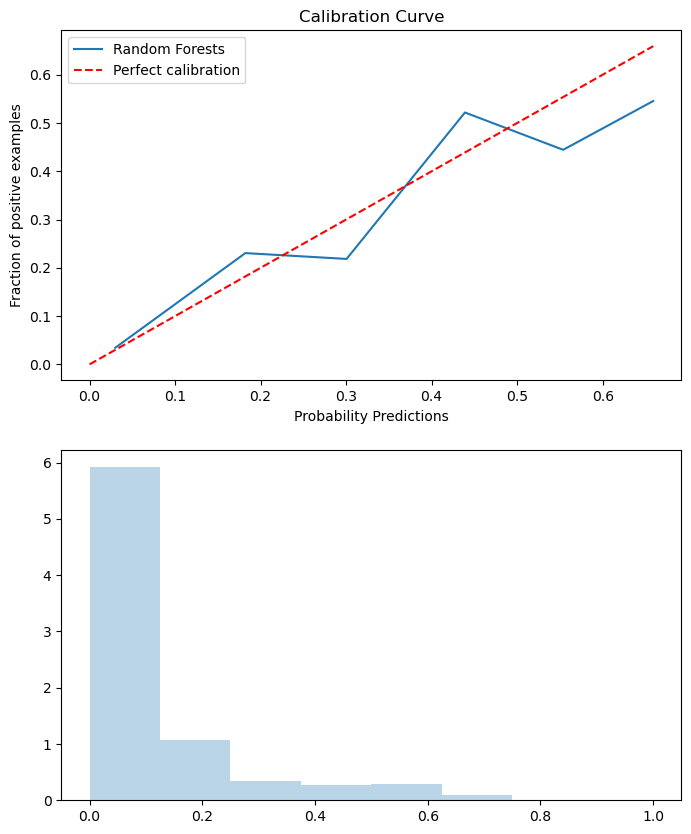

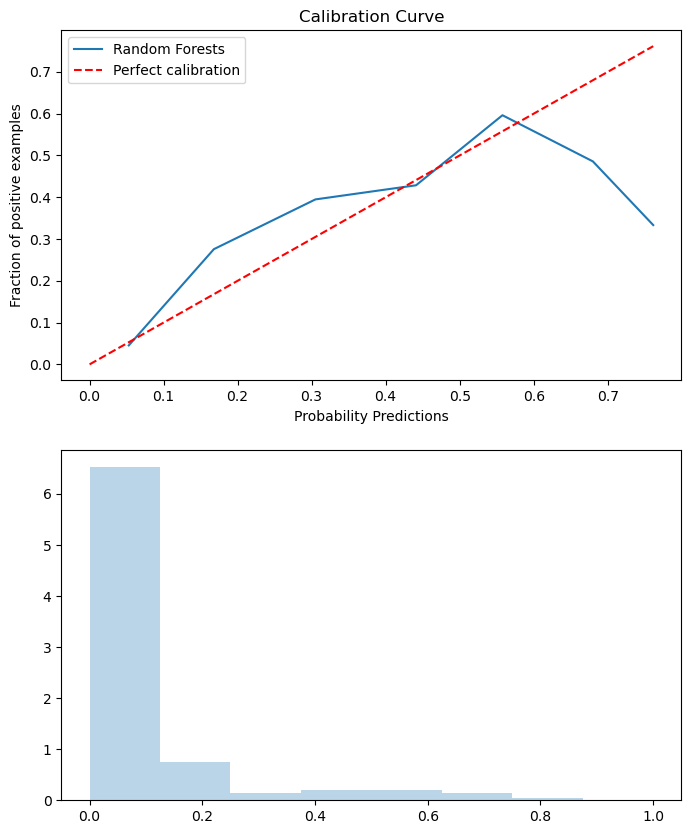

Optimal threshold for F2 score: 0.09
Optimal threshold for MCC: 0.18000000000000002


,Model,Threshold,F2 Score,MCC
0,LightGBM,0.01,0.460123,0.209119
1,LightGBM,0.02,0.516642,0.278343
2,LightGBM,0.03,0.536088,0.300176
3,LightGBM,0.04,0.541065,0.305276
4,LightGBM,0.05,0.548066,0.315216
...,...,...,...,...
95,LightGBM,0.96,0.0,0.0
96,LightGBM,0.97,0.0,0.0
97,LightGBM,0.98,0.0,0.0
98,LightGBM,0.99,0.0,0.0


In [43]:
best_estimator_lgbm, best_params_lgbm, best_score_lgbm = grid_search(pipeline_lgbm, lgbm_parameters, X_train, y_train)
clean_params_lgbm = {k.replace('classifier__', ''): v for k, v in best_params_lgbm.items()}
tuned_pipeline_lgbm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LGBMClassifier(
        scale_pos_weight=1,
        random_state=42,
        **clean_params_lgbm
    ))
])

calibrated_lgbm = calibrate_and_plot(tuned_pipeline_lgbm, X_train, y_train, X_test, y_test)
oof_probs_lgbm = generate_oof_predictions(tuned_pipeline_lgbm, X_train, y_train)
thresh_f2_lgbm, thresh_mcc_lgbm, threshold_df_lgbm = optimize_thresholds("LightGBM", y_test, tuned_pipeline_lgbm.predict_proba(X_test)[:, 1])
print("Optimal threshold for F2 score:", thresh_f2_lgbm)
print("Optimal threshold for MCC:", thresh_mcc_lgbm)
threshold_df_lgbm

## Statistical Bootstrap Analysis

In [47]:
def stratified_bootstrap_ci_f2(model, X_test, y_test, threshold, n_bootstraps=1000, alpha=0.95):
    # Define lists to hold bootstrap scores
    boot_f2_scores = []
    
    # Isolate class indices for stratification
    class_0_indices = np.where(y_test == 0)[0]
    class_1_indices = np.where(y_test == 1)[0]
    
    # Get predicted probabilities for the test set
    test_probs = model.predict_proba(X_test)[:, 1]
    
    for _ in range(n_bootstraps):
        # Stratified sampling: sample with replacement within each class
        boot_class_0 = np.random.choice(class_0_indices, size=len(class_0_indices), replace=True)
        boot_class_1 = np.random.choice(class_1_indices, size=len(class_1_indices), replace=True)
        boot_indices = np.concatenate([boot_class_0, boot_class_1])
        
        # Get the bootstrap sample
        y_boot = y_test.iloc[boot_indices]
        probs_bool = test_probs[boot_indices]
        y_boot_pred = (probs_bool >= threshold).astype(int)
        
        boot_f2_scores.append(fbeta_score(y_boot, y_boot_pred, beta=2, zero_division=0))
    
    # Find the confidence intervals
    f2_ci = np.percentile(boot_f2_scores, [(1 - alpha) / 2 * 100, (1 + alpha) / 2 * 100])
    
    return f2_ci

def stratified_bootstrap_ci_mcc(model, X_test, y_test, threshold, n_bootstraps=1000, alpha=0.95):
    # Define lists to hold bootstrap scores
    boot_mcc_scores = []
    
    # Isolate class indices for stratification
    class_0_indices = np.where(y_test == 0)[0]
    class_1_indices = np.where(y_test == 1)[0]
    
    # Get predicted probabilities for the test set
    test_probs = model.predict_proba(X_test)[:, 1]
    
    for _ in range(n_bootstraps):
        # Stratified sampling: sample with replacement within each class
        boot_class_0 = np.random.choice(class_0_indices, size=len(class_0_indices), replace=True)
        boot_class_1 = np.random.choice(class_1_indices, size=len(class_1_indices), replace=True)
        boot_indices = np.concatenate([boot_class_0, boot_class_1])
        
        # Get the bootstrap sample
        y_boot = y_test.iloc[boot_indices]
        probs_bool = test_probs[boot_indices]
        y_boot_pred = (probs_bool >= threshold).astype(int)
        
        boot_mcc_scores.append(matthews_corrcoef(y_boot, y_boot_pred))
        
    # Find the confidence intervals
    mcc_ci = np.percentile(boot_mcc_scores, [(1 - alpha) / 2 * 100, (1 + alpha) / 2 * 100])
    
    return mcc_ci

In [52]:
f2_cl_baseline_f2 = stratified_bootstrap_ci_f2(baseline_model, X_test_baseline, y_test_baseline, thresh_f2_lr)
f2_cl_baseline_mcc = stratified_bootstrap_ci_mcc(baseline_model, X_test_baseline, y_test_baseline, thresh_f2_lr)
print(f"Baseline Model - F2 Score 95% CI: {f2_cl_baseline_f2}, MCC 95% CI: {f2_cl_baseline_mcc}")
f2_cl_lr_f2 = stratified_bootstrap_ci_f2(calibrated_lr, X_test, y_test, thresh_f2_lr)
f2_cl_lr_mcc = stratified_bootstrap_ci_mcc(calibrated_lr, X_test, y_test, thresh_f2_lr)
print(f"Logistic Regression - F2 Score 95% CI: {f2_cl_lr_f2}, MCC 95% CI: {f2_cl_lr_mcc}")
f2_cl_rf_f2 = stratified_bootstrap_ci_f2(calibrated_rf, X_test, y_test, thresh_f2_rf)
f2_cl_rf_mcc = stratified_bootstrap_ci_mcc(calibrated_rf, X_test, y_test, thresh_f2_rf)
print(f"Random Forest - F2 Score 95% CI: {f2_cl_rf_f2}, MCC 95% CI: {f2_cl_rf_mcc}")
f2_cl_xgb_f2 = stratified_bootstrap_ci_f2(calibrated_xgb, X_test, y_test, thresh_f2_xgb)
f2_cl_xgb_mcc = stratified_bootstrap_ci_mcc(calibrated_xgb, X_test, y_test, thresh_f2_xgb)
print(f"XGBoost - F2 Score 95% CI: {f2_cl_xgb_f2}, MCC 95% CI: {f2_cl_xgb_mcc}")
f2_cl_lgbm_f2 = stratified_bootstrap_ci_f2(calibrated_lgbm, X_test, y_test, thresh_f2_lgbm)
f2_cl_lgbm_mcc = stratified_bootstrap_ci_mcc(calibrated_lgbm, X_test, y_test, thresh_f2_lgbm)
print(f"LightGBM - F2 Score 95% CI: {f2_cl_lgbm_f2}, MCC 95% CI: {f2_cl_lgbm_mcc}")

Baseline Model - F2 Score 95% CI: [0.18959913 0.30786561], MCC 95% CI: [0.21989504 0.35843894]
Logistic Regression - F2 Score 95% CI: [0.22529782 0.35270475], MCC 95% CI: [0.25735457 0.40620899]
Random Forest - F2 Score 95% CI: [0.4897098  0.60000822], MCC 95% CI: [0.34398953 0.45286505]
XGBoost - F2 Score 95% CI: [0.53844937 0.61512954], MCC 95% CI: [0.33104007 0.41122261]
LightGBM - F2 Score 95% CI: [0.54961311 0.63493108], MCC 95% CI: [0.36002051 0.44224631]


## McNemar Test and Cochran's Q Test

In [72]:
y_pred_baseline = (baseline_model.predict_proba(X_test_baseline)[:, 1] >= 0.5).astype(int)

y_pred_lr_f2 = (calibrated_lr.predict_proba(X_test)[:, 1] >= thresh_f2_lr).astype(int)
y_pred_rf_f2 = (calibrated_rf.predict_proba(X_test)[:, 1] >= thresh_f2_rf).astype(int)
y_pred_xgb_f2 = (calibrated_xgb.predict_proba(X_test)[:, 1] >= thresh_f2_xgb).astype(int)
y_pred_lgbm_f2 = (calibrated_lgbm.predict_proba(X_test)[:, 1] >= thresh_f2_lgbm).astype(int)

y_pred_lr_mcc = (calibrated_lr.predict_proba(X_test)[:, 1] >= thresh_mcc_lr).astype(int)
y_pred_rf_mcc = (calibrated_rf.predict_proba(X_test)[:, 1] >= thresh_mcc_rf).astype(int)
y_pred_xgb_mcc = (calibrated_xgb.predict_proba(X_test)[:, 1] >= thresh_mcc_xgb).astype(int)
y_pred_lgbm_mcc = (calibrated_lgbm.predict_proba(X_test)[:, 1] >= thresh_mcc_lgbm).astype(int)

# McNemar's test
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    y_true_np = np.array(y_true).astype(int)
    y_pred_a_np = np.array(y_pred_a).astype(int)
    y_pred_b_np = np.array(y_pred_b).astype(int)
    
    table = mcnemar_table(y_true_np, y_pred_a_np, y_pred_b_np)
    
    # Check all off-diagonal elements
    discordant = table[0,1] + table[1,0]
    print(f"Discordant pairs: {discordant}")
    
    if discordant == 0:
        return None, None
    
    result = sm_mcnemar(table, exact=True, correction=True)
    return result.statistic, result.pvalue

# Cochran's Q test for multiple models
def cochrans_q_test(y_true, *y_preds):
    y_true_np = np.array(y_true).astype(int)
    y_preds_np = [np.array(y).astype(int) for y in y_preds]
    q, p = cochrans_q(y_true_np, *y_preds_np)
    return q, p

# Compare baseline to each model using McNemar's test
models_f2 = {
    'Logistic Regression': y_pred_lr_f2,
    'Random Forest': y_pred_rf_f2,
    'XGBoost': y_pred_xgb_f2,
    'LightGBM': y_pred_lgbm_f2
}
for model_name, y_pred in models_f2.items():
    chi2, p = mcnemar_test(y_test, y_pred_baseline, y_pred)
    if chi2 is not None:
        print(f"McNemar's test comparing Baseline to {model_name} (F2 threshold): chi2={chi2:.4f}, p={p:.4f}")
    else:
        print(f"McNemar's test comparing Baseline is not valid for {model_name} (F2 threshold) due to no discordant pairs.")

models_mcc = {
    'Logistic Regression': y_pred_lr_mcc,
    'Random Forest': y_pred_rf_mcc,
    'XGBoost': y_pred_xgb_mcc,
    'LightGBM': y_pred_lgbm_mcc
}
for model_name, y_pred in models_mcc.items():
    chi2, p = mcnemar_test(y_test, y_pred_baseline, y_pred)
    if chi2 is not None:
        print(f"McNemar's test comparing Baseline to {model_name} (MCC threshold): chi2={chi2:.4f}, p={p:.4f}")
    else:
        print(f"McNemar's test comparing Baseline is not valid for {model_name} (MCC threshold) due to no discordant pairs.")

# Cochran's Q test comparing all models at once (F2 threshold)
q_f2, p_f2 = cochrans_q_test(y_test, y_pred_baseline, y_pred_lr_f2, y_pred_rf_f2, y_pred_xgb_f2, y_pred_lgbm_f2)
print(f"Cochran's Q test comparing all models (F2 threshold): Q={q_f2:.4f}, p={p_f2:.4f}")

# Cochran's Q test comparing all models at once (MCC threshold)
q_mcc, p_mcc = cochrans_q_test(y_test, y_pred_baseline, y_pred_lr_mcc, y_pred_rf_mcc, y_pred_xgb_mcc, y_pred_lgbm_mcc)
print(f"Cochran's Q test comparing all models (MCC threshold): Q={q_mcc:.4f}, p={p_mcc:.4f}")

Discordant pairs: 59
McNemar's test comparing Baseline to Logistic Regression (F2 threshold): chi2=24.0000, p=0.1925
Discordant pairs: 259
McNemar's test comparing Baseline to Random Forest (F2 threshold): chi2=84.0000, p=0.0000
Discordant pairs: 497
McNemar's test comparing Baseline to XGBoost (F2 threshold): chi2=118.0000, p=0.0000
Discordant pairs: 405
McNemar's test comparing Baseline to LightGBM (F2 threshold): chi2=111.0000, p=0.0000
Discordant pairs: 59
McNemar's test comparing Baseline to Logistic Regression (MCC threshold): chi2=24.0000, p=0.1925
Discordant pairs: 123
McNemar's test comparing Baseline to Random Forest (MCC threshold): chi2=54.0000, p=0.2066
Discordant pairs: 137
McNemar's test comparing Baseline to XGBoost (MCC threshold): chi2=51.0000, p=0.0035
Discordant pairs: 154
McNemar's test comparing Baseline to LightGBM (MCC threshold): chi2=57.0000, p=0.0016
Cochran's Q test comparing all models (F2 threshold): Q=380.2402, p=0.0000
Cochran's Q test comparing all mode

In [67]:
# Check types and shapes
print(type(y_test), type(y_pred_baseline), type(y_pred_lr_f2))
print(y_test.shape, y_pred_baseline.shape, y_pred_lr_f2.shape)

# Check if predictions are actually different
print("Baseline vs LR disagreements:", (y_pred_baseline != y_pred_lr_f2).sum())
print("Baseline vs RF disagreements:", (y_pred_baseline != y_pred_rf_f2).sum())

# Check the actual contingency table
table = mcnemar_table(y_test.values, y_pred_baseline, y_pred_lr_f2)
print("Contingency table:")
print(table)

<class 'pandas.Series'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>
(2000,) (2000,) (2000,)
Baseline vs LR disagreements: 59
Baseline vs RF disagreements: 259
Contingency table:
[[1765   24]
 [  35  176]]
